# Experiment 1: Quick vs Full Run – Visual Comparison

Comparing the **Quick** (early-cancelled) and **Full** (complete) cluster runs side by side.

- Quick run finished only a subset of datasets before cancellation.
- Full run covers more datasets and includes the same method suite.
- The next cell summarizes which datasets were evaluated in each run.

**Methods assessed:** Med3-TabPFN • Med3-LoCalPFN • DenseNet121-3D • ViT-3D

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

RUN_COLORS = {'Quick': '#FF6B6B', 'Full': '#4ECDC4'}
METHOD_COLORS = {
    'tabpfn': '#E74C3C',
    'localpfn': '#3498DB',
    'densenet121_3d': '#2ECC71',
    'vit3d': '#F39C12'
}

In [46]:
import pandas as pd
from pathlib import Path

# Load CSVs
repo_root = Path.cwd().parent.parent
quick_csv = repo_root / 'results_from_cluster' / 'combined_benchmarks_summary.csv'
full_csv = repo_root / 'results' / 'experiment1' / 'combined_benchmarks_summary.csv'

df_quick = pd.read_csv(quick_csv)
df_full = pd.read_csv(full_csv)

# Identify coverage
quick_done = set(df_quick[df_quick['accuracy'].notna()]['dataset'])
full_done = set(df_full[df_full['accuracy'].notna()]['dataset'])

coverage = pd.DataFrame({
    'Dataset': sorted(quick_done | full_done)
})
coverage['Quick Run'] = coverage['Dataset'].apply(lambda d: '✅' if d in quick_done else '—')
coverage['Full Run'] = coverage['Dataset'].apply(lambda d: '✅' if d in full_done else '—')
coverage['Status'] = coverage.apply(
    lambda row: 'Both' if row['Quick Run'] == '✅' and row['Full Run'] == '✅'
    else ('Quick only' if row['Quick Run'] == '✅' else 'Full only'),
    axis=1
)

coverage.set_index('Dataset')

,Quick Run,Full Run,Status
Dataset,,,
crlm,✅,✅,Both
gist,✅,✅,Both
lipo,✅,✅,Both
melanoma,—,✅,Full only


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

RUN_COLORS = {'Quick': '#FF6B6B', 'Full': '#4ECDC4'}
METHOD_COLORS = {'tabpfn': '#E74C3C', 'localpfn': '#3498DB', 'densenet121_3d': '#2ECC71', 'vit3d': '#F39C12'}

repo_root = Path.cwd().parent.parent
df_quick = pd.read_csv(repo_root / 'results_from_cluster' / 'combined_benchmarks_summary.csv')
df_full = pd.read_csv(repo_root / 'results' / 'experiment1' / 'combined_benchmarks_summary.csv')

df_quick['run'] = 'Quick'
df_full['run'] = 'Full'
df_quick_valid = df_quick[df_quick['accuracy'].notna()]
df_full_valid = df_full[df_full['accuracy'].notna()]
df_combined = pd.concat([df_quick_valid, df_full_valid])

print(f"📊 Quick: {len(df_quick_valid)} results | Full: {len(df_full_valid)} results")

📊 Quick: 11 results | Full: 15 results


## 1. Overall Performance Comparison

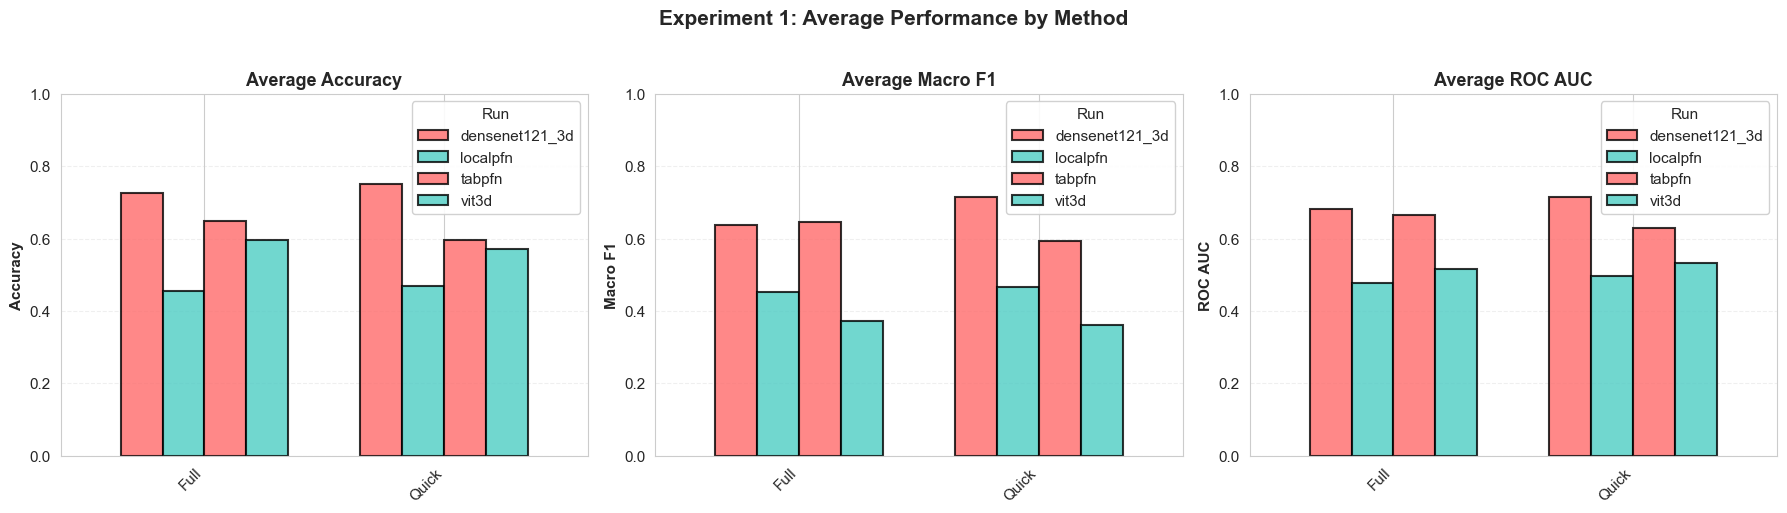

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (metric, name) in zip(axes, [('accuracy', 'Accuracy'), ('macro_f1', 'Macro F1'), ('roc_auc', 'ROC AUC')]):
    avg_data = df_combined.groupby(['run', 'method'])[metric].mean().unstack(fill_value=0)
    avg_data.plot(kind='bar', ax=ax, color=[RUN_COLORS['Quick'], RUN_COLORS['Full']], 
                  edgecolor='black', linewidth=1.5, alpha=0.8, width=0.7)
    
    ax.set_ylabel(name, fontweight='bold')
    ax.set_title(f'Average {name}', fontweight='bold', fontsize=13)
    ax.set_xlabel('')
    ax.set_ylim(0, 1)
    ax.legend(title='Run', framealpha=0.9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle('Experiment 1: Average Performance by Method', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 2. ROC AUC Heatmaps

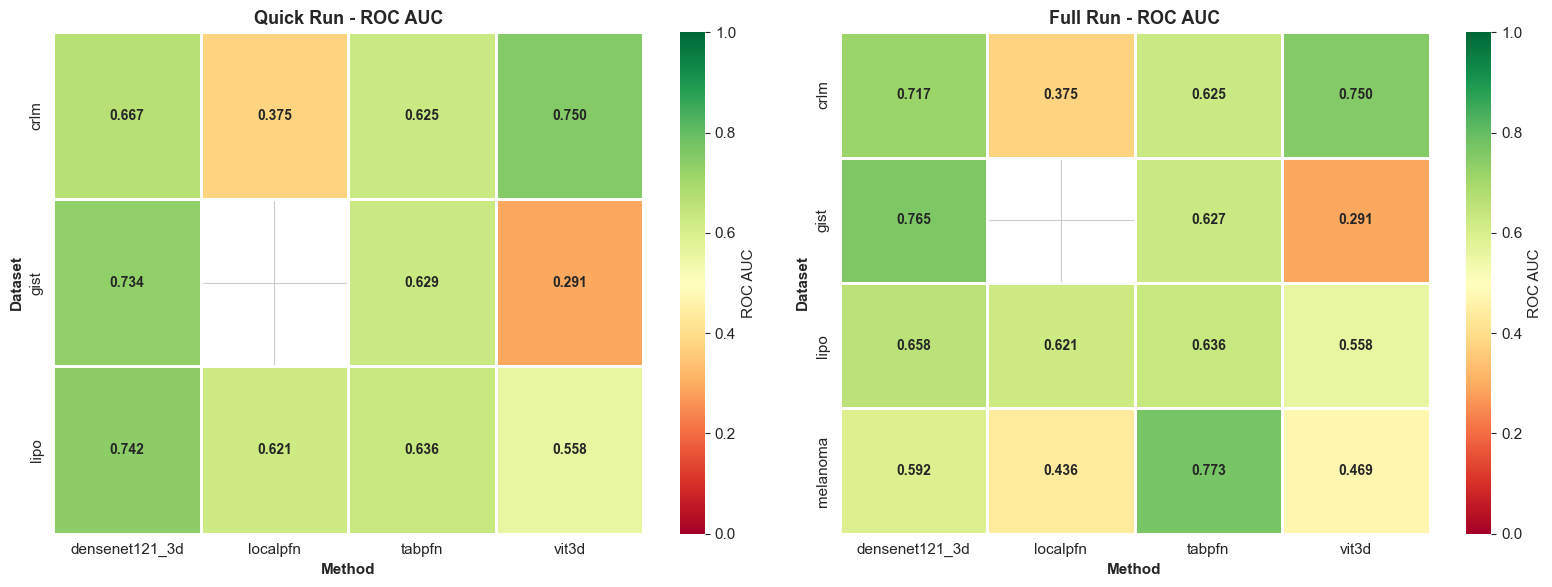

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (df_data, title) in zip(axes, [(df_quick_valid, 'Quick Run'), (df_full_valid, 'Full Run')]):
    pivot = df_data.pivot_table(index='dataset', columns='method', values='roc_auc')
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1, ax=ax,
                linewidths=2, linecolor='white', cbar_kws={'label': 'ROC AUC'},
                annot_kws={'fontsize': 10, 'fontweight': 'bold'})
    ax.set_title(f'{title} - ROC AUC', fontweight='bold', fontsize=13)
    ax.set_xlabel('Method', fontweight='bold')
    ax.set_ylabel('Dataset', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Direct Comparison Scatter

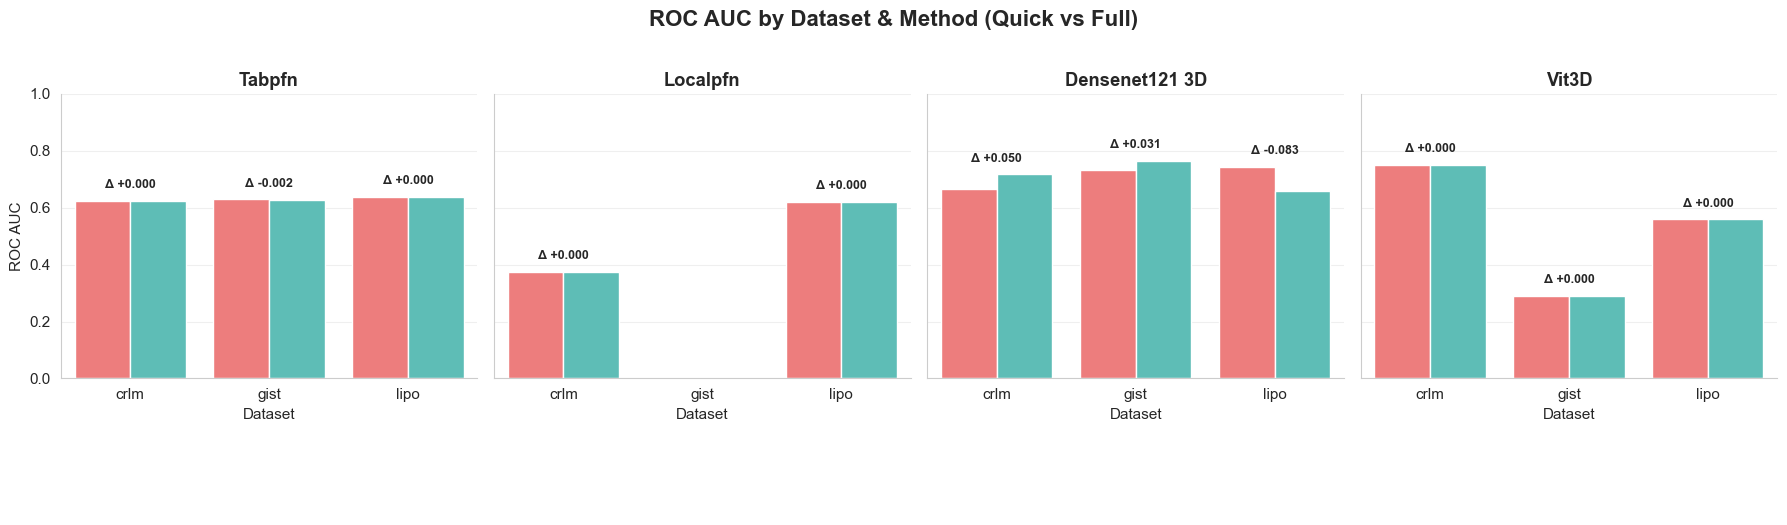


✅ 11 common dataset–method pairs compared


In [50]:
df_comp = pd.merge(
    df_quick_valid[['dataset', 'method', 'roc_auc']].rename(columns={'roc_auc': 'roc_auc_quick'}),
    df_full_valid[['dataset', 'method', 'roc_auc']].rename(columns={'roc_auc': 'roc_auc_full'}),
    on=['dataset', 'method']
)

if len(df_comp) > 0:
    long_comp = df_comp.melt(
        id_vars=['dataset', 'method'],
        value_vars=['roc_auc_quick', 'roc_auc_full'],
        var_name='run_tag',
        value_name='roc_auc'
    )
    long_comp['run'] = long_comp['run_tag'].map({
        'roc_auc_quick': 'Quick run',
        'roc_auc_full': 'Full run'
    })

    dataset_order = sorted(long_comp['dataset'].unique())
    method_order = ['tabpfn', 'localpfn', 'densenet121_3d', 'vit3d']

    g = sns.catplot(
        data=long_comp,
        x='dataset', y='roc_auc', hue='run', col='method',
        kind='bar', palette=[RUN_COLORS['Quick'], RUN_COLORS['Full']],
        order=dataset_order,
        col_order=[m for m in method_order if m in long_comp['method'].unique()],
        height=4.2, aspect=1.0
    )

    for ax, method in zip(g.axes.flat, g.col_names):
        ax.set_title(method.replace('_', ' ').title(), fontweight='bold')
        ax.set_xlabel('Dataset')
        ax.set_ylabel('ROC AUC')
        ax.set_ylim(0, 1)
        ax.grid(axis='y', alpha=0.3)

        subset = df_comp[df_comp['method'] == method]
        for idx, row in subset.iterrows():
            quick_val = row['roc_auc_quick']
            full_val = row['roc_auc_full']
            diff = full_val - quick_val
            x_pos = dataset_order.index(row['dataset'])
            ax.text(
                x_pos, max(quick_val, full_val) + 0.035,
                f"Δ {diff:+.3f}", ha='center', va='bottom', fontsize=9, fontweight='bold'
            )

    g.fig.suptitle('ROC AUC by Dataset & Method (Quick vs Full)', fontsize=16, fontweight='bold', y=1.02)
    g._legend.set_title('Run')
    for text in g._legend.texts:
        text.set_fontsize(10)
    g._legend.get_texts()[0].set_text('Quick run')
    g._legend.get_texts()[1].set_text('Full run')
    g._legend.set_bbox_to_anchor((0.5, -0.1))
    g._legend.set_title('Run')
    g._legend.set_frame_on(True)
    g._legend.get_frame().set_edgecolor('black')

    plt.tight_layout()
    plt.show()

    print(f"\n✅ {len(df_comp)} common dataset–method pairs compared")
else:
    print("⚠️ No common datasets")

## 4. Numeric Summaries

In [51]:
# Table 1: metrics per dataset & method (Quick vs Full)
metrics_cols = ['accuracy', 'macro_f1', 'roc_auc']

combined_runs = pd.concat([
    df_quick_valid.assign(run='Quick'),
    df_full_valid.assign(run='Full')
])

summary_table = (
    combined_runs
    .pivot_table(
        index=['dataset', 'method'],
        columns='run',
        values=metrics_cols
    )
    .sort_index()
)

# High-level aggregates for a quick read
method_summary = (
    combined_runs.groupby(['method', 'run'])[metrics_cols]
    .mean()
    .unstack('run')
    .round(3)
)
dataset_summary = (
    combined_runs.groupby(['dataset', 'run'])[metrics_cols]
    .mean()
    .unstack('run')
    .round(3)
)

print('Average metrics by method (rows) and run (columns):')
display(method_summary)

print('\nAverage metrics by dataset (rows) and run (columns):')
display(dataset_summary)

print('\nPer-dataset breakdown (methods as rows):')
for dataset in sorted(summary_table.index.get_level_values('dataset').unique()):
    print(f"\nDataset: {dataset}")
    dataset_table = summary_table.loc[dataset].round(3)
    dataset_table.columns = [f"{metric} ({run})" for metric, run in dataset_table.columns]
    display(dataset_table)


Average metrics by method (rows) and run (columns):


accuracy        macro_f1        roc_auc       
run                Full  Quick     Full  Quick    Full  Quick
method                                                       
densenet121_3d    0.725  0.751    0.638  0.715   0.683  0.714
localpfn          0.456  0.470    0.453  0.466   0.478  0.498
tabpfn            0.650  0.596    0.647  0.594   0.665  0.630
vit3d             0.596  0.572    0.371  0.362   0.517  0.533


Average metrics by dataset (rows) and run (columns):


accuracy        macro_f1        roc_auc       
run          Full  Quick     Full  Quick    Full  Quick
dataset                                                
crlm        0.609  0.609    0.549  0.545   0.617  0.604
gist        0.573  0.580    0.518  0.521   0.561  0.551
lipo        0.630  0.630    0.551  0.551   0.619  0.639
melanoma    0.643    NaN    0.508    NaN   0.568    NaN


Per-dataset breakdown (methods as rows):

Dataset: crlm


...

,accuracy (Full),accuracy (Quick),macro_f1 (Full),macro_f1 (Quick),roc_auc (Full),roc_auc (Quick)
method,,,,,,
densenet121_3d,0.70,0.72,0.670,0.678,0.765,0.734
tabpfn,0.58,0.58,0.578,0.578,0.627,0.629
vit3d,0.44,0.44,0.306,0.306,0.291,0.291



Dataset: lipo


,accuracy (Full),accuracy (Quick),macro_f1 (Full),macro_f1 (Quick),roc_auc (Full),roc_auc (Quick)
method,,,,,,
densenet121_3d,0.783,0.783,0.732,0.732,0.658,0.742
localpfn,0.565,0.565,0.558,0.558,0.621,0.621
tabpfn,0.522,0.522,0.518,0.518,0.636,0.636
vit3d,0.652,0.652,0.395,0.395,0.558,0.558



Dataset: melanoma


,accuracy (Full),accuracy (Quick),macro_f1 (Full),macro_f1 (Quick),roc_auc (Full),roc_auc (Quick)
method,,,,,,
densenet121_3d,0.667,NaN,0.400,NaN,0.592,NaN
localpfn,0.429,NaN,0.427,NaN,0.436,NaN
tabpfn,0.810,NaN,0.806,NaN,0.773,NaN
vit3d,0.667,NaN,0.400,NaN,0.469,NaN


## 5. Method Rankings

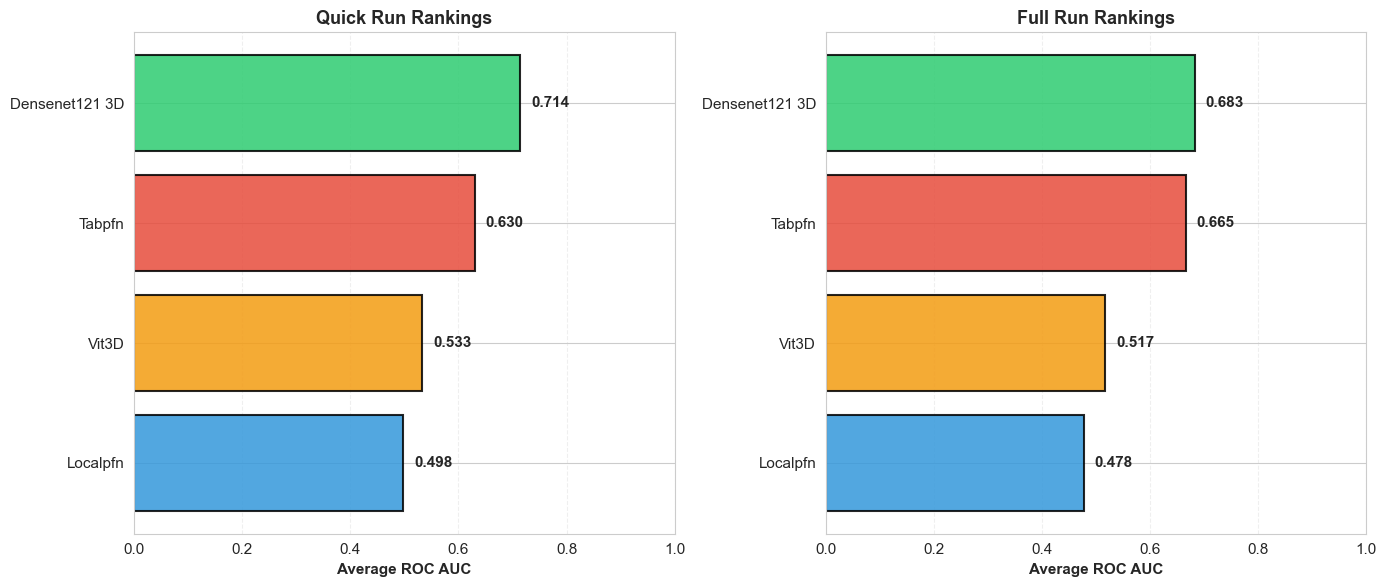

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (df_data, title) in zip(axes, [(df_quick_valid, 'Quick'), (df_full_valid, 'Full')]):
    avg = df_data.groupby('method')['roc_auc'].mean().sort_values()
    colors = [METHOD_COLORS.get(m, 'gray') for m in avg.index]
    
    ax.barh(range(len(avg)), avg.values, color=colors, edgecolor='black', linewidth=1.5, alpha=0.85)
    ax.set_yticks(range(len(avg)))
    ax.set_yticklabels([m.replace('_', ' ').title() for m in avg.index])
    ax.set_xlabel('Average ROC AUC', fontweight='bold')
    ax.set_title(f'{title} Run Rankings', fontweight='bold', fontsize=13)
    ax.set_xlim(0, 1)
    
    for i, val in enumerate(avg.values):
        ax.text(val + 0.02, i, f'{val:.3f}', va='center', fontweight='bold')
    ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()